# Trabajo final IA, Santos Santiago, Wagner Mateo

### Conclusiones y análisis todo junto sobre el final.

# 0. Instalación y descarga de dataset.

In [ ]:
# @title importar libs, descargar dataset, definicion de funciones para entrenar, evaluar y graficar
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras import layers, Sequential, applications, regularizers
from tensorflow.keras.callbacks import EarlyStopping

# setear seeds para que todas las runs sean iguales
tf.random.set_seed(42)
np.random.seed(42)

# cargamos el dataset cifar-10
(imagenes_entrenamiento, etiquetas_entrenamiento), (imagenes_validacion, etiquetas_validacion) = keras.datasets.cifar10.load_data()

# imagenes_entrenamiento = imagenes_entrenamiento.astype('float32')/255.0
# imagenes_validacion = imagenes_validacion.astype('float32')/255.0

# PARA EFFICIENT NET NO NORMALIZAR!!! usa 0-255

imagenes_entrenamiento = imagenes_entrenamiento.astype('float32')
imagenes_validacion = imagenes_validacion.astype('float32')

# one-hot encoding, asignar vector numerico a las clases..
cant_clases = 10
etiquetas_entrenamiento = keras.utils.to_categorical(etiquetas_entrenamiento, cant_clases)
etiquetas_validacion = keras.utils.to_categorical(etiquetas_validacion, cant_clases)

# grafica el historial desde la primer epoch en esta tanda de entrenamiento
# y genera la cm con las imagenes de validacion en la epoch con menor val_loss (la que haya decidido como mejor el early stopping)
def graficar_resultados(history, nombre, modelo, ds_validacion):
  fig, ax = plt.subplots(1, 2, figsize=(15, 6))
  ax[0].plot(history.history['accuracy'], label='imagenes entrenamiento')
  ax[0].plot(history.history['val_accuracy'], label='imagenes test')
  ax[0].set_title(f'{nombre} - Accuracy')
  ax[0].set_xlabel('Epochs')
  ax[0].set_ylabel('Accuracy')
  ax[0].legend()
  verdaderas = np.argmax(etiquetas_validacion, axis=1)
  predicciones = np.argmax(modelo.predict(ds_validacion, verbose=0), axis=1)
  cm = confusion_matrix(verdaderas, predicciones)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Avión','Auto','Pájaro','Gato','Ciervo','Perro','Rana','Caballo','Barco','Camión'])
  disp.plot(cmap="Blues", xticks_rotation=45, ax=ax[1], colorbar=True)
  ax[1].set_title("Matriz de confusión")
  plt.tight_layout()
  plt.show()

def entrenar_y_evaluar(modelo, nombre, epochs, rate=0, loss='categorical_crossentropy', data_aug=False):
  print(f"\n--- Entrenando: {nombre} por {epochs} epochs, rate: {rate} (0 = default), loss: {loss} ---")
  modelo.summary()

  early_stop = EarlyStopping(
      monitor='val_loss',
      patience=10, # epochs sin mejora necesarias para frenar el entrenamiento
      restore_best_weights=True,
      verbose=1
  )

  if rate != 0: #pasar rate = 0 se comporta como default, no como realmente 0 ya que no aprendería nada.
    modelo.compile(optimizer=keras.optimizers.Adam(rate),loss=loss,metrics=['accuracy'])
  else:
    modelo.compile(optimizer='adam',loss=loss,metrics=['accuracy'])

  batch_size = 128
  ds_entrenamiento = tf.data.Dataset.from_tensor_slices((imagenes_entrenamiento, etiquetas_entrenamiento))
  ds_entrenamiento = ds_entrenamiento.shuffle(10000).batch(batch_size)

  if data_aug:
      data_augmentation_layers = tf.keras.Sequential([
          layers.RandomFlip("horizontal"),
          layers.RandomRotation(0.1), # Rota un 10%
          layers.RandomZoom(0.1),     # Zoom in/out aleatorio del 10%
      ])
      ds_entrenamiento = ds_entrenamiento.map(
          lambda x, y: (data_augmentation_layers(x, training=True), y),
          num_parallel_calls=tf.data.AUTOTUNE
      )

  ds_entrenamiento = ds_entrenamiento.prefetch(tf.data.AUTOTUNE)
  ds_validacion = tf.data.Dataset.from_tensor_slices((imagenes_validacion, etiquetas_validacion)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

  history = modelo.fit(ds_entrenamiento, epochs=epochs, validation_data=ds_validacion, callbacks=[early_stop], verbose=1)

  # evaluar tanto con las imgs de entrenamiento como con las de validacion
  # medio de sobra ya que igual sale en los graficos pero bueno, da el nro exacto que en el grafico no se ve
  test_loss, test_acc = modelo.evaluate(ds_validacion, verbose=0)
  print(f"\nAccuracy en validacion para {nombre}: {test_acc:.4f}")
  entrenar_loss, entrenar_acc = modelo.evaluate(ds_entrenamiento, verbose=0)
  print(f"\nAccuracy en entrenados para {nombre}: {entrenar_acc:.4f}")

  graficar_resultados(history, nombre, modelo, ds_validacion)

  return modelo


# 1. Redes de layers densas


--- Entrenando: densa Simple por 25 epochs, rate: 0 (0 = default), loss: categorical_crossentropy ---


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,157,002 (12.04 MB)

 Trainable params: 3,157,002 (12.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.2366 - loss: 3.1677 - val_accuracy: 0.3597 - val_loss: 2.1992
Epoch 2/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.3392 - loss: 2.1635 - val_accuracy: 0.3760 - val_loss: 1.9682
Epoch 3/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.3713 - loss: 1.9705 - val_accuracy: 0.4058 - val_loss: 1.8227
Epoch 4/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.3842 - loss: 1.8552 - val_accuracy: 0.4011 - val_loss: 1.7749
Epoch 5/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.4003 - loss: 1.7819 - val_accuracy: 0.4131 - val_loss: 1.7108
Epoch 6/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.3989 - loss: 1.7599 - val_accuracy: 0.4213 - val_loss: 1.6970
Epoch 7/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.4053 - loss: 1.7284 - val_accuracy: 0.4463 - val_loss: 1.6407
Epoch 8/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.4116 - loss: 1.7140 - va

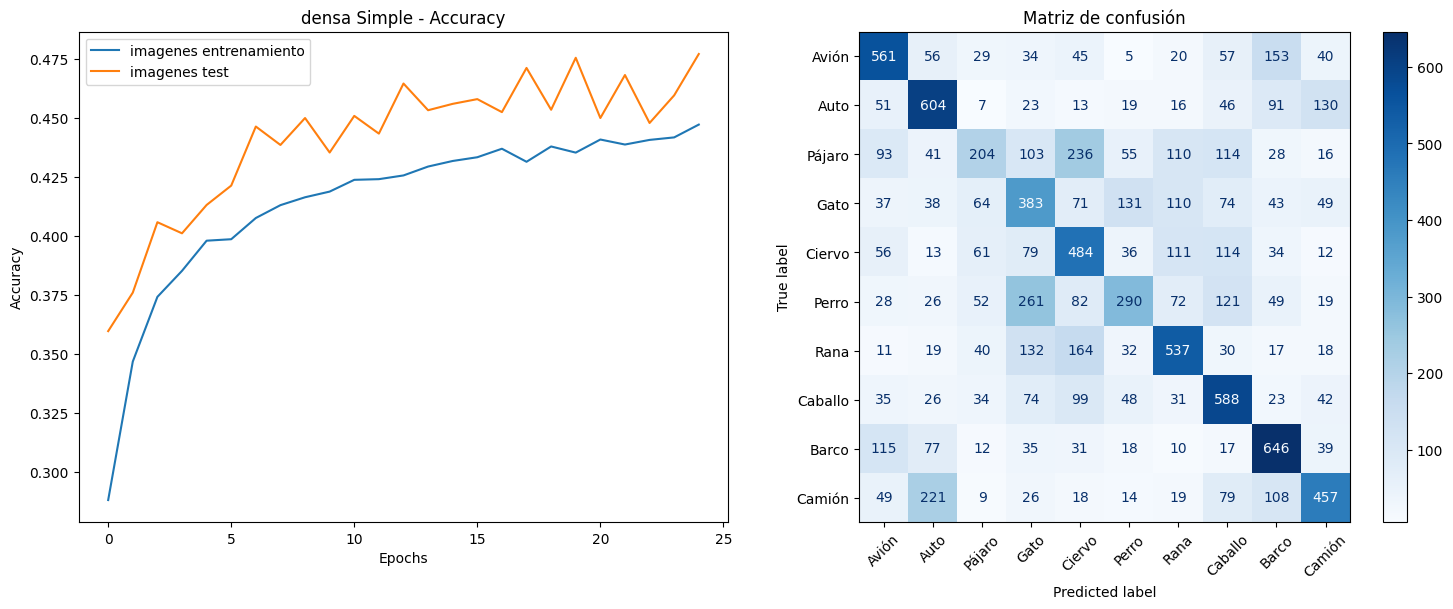

<Sequential name=sequential_13, built=True>

In [ ]:
# @title red simple de una sola capa oculta con regularizacion
def crear_densa_simple():
    model = Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Flatten(), # aplanamos la imagen 32x32x3 a un vector
        layers.Dense(1024, activation='relu',kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)), # activación relu ya que es hidden layer
        layers.Dense(cant_clases, activation='softmax') # capa de salida con activacion softmax
    ])
    return model



model_densa1 = crear_densa_simple()
entrenar_y_evaluar(model_densa1, "densa Simple", 25, data_aug = True)


--- Entrenando: DNN Profunda por 20 epochs, rate: 0 (0 = default), loss: categorical_crossentropy ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,846,442 (14.67 MB)

 Trainable params: 3,846,442 (14.67 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - accuracy: 0.1251 - loss: 2.2832 - val_accuracy: 0.2351 - val_loss: 2.0179
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.2356 - loss: 2.0267 - val_accuracy: 0.2867 - val_loss: 1.9317
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.2755 - loss: 1.9523 - val_accuracy: 0.3235 - val_loss: 1.8615
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.2943 - loss: 1.9105 - val_accuracy: 0.3351 - val_loss: 1.8156
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.3070 - loss: 1.8871 - val_accuracy: 0.3582 - val_loss: 1.7746
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.3219 - loss: 1.8602 - val_accuracy: 0.3662 - val_loss: 1.7478
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3259 - loss: 1.8422 - val_accuracy: 0.3588 - val_loss: 1.7676
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.3327 - loss: 1.8347 - 

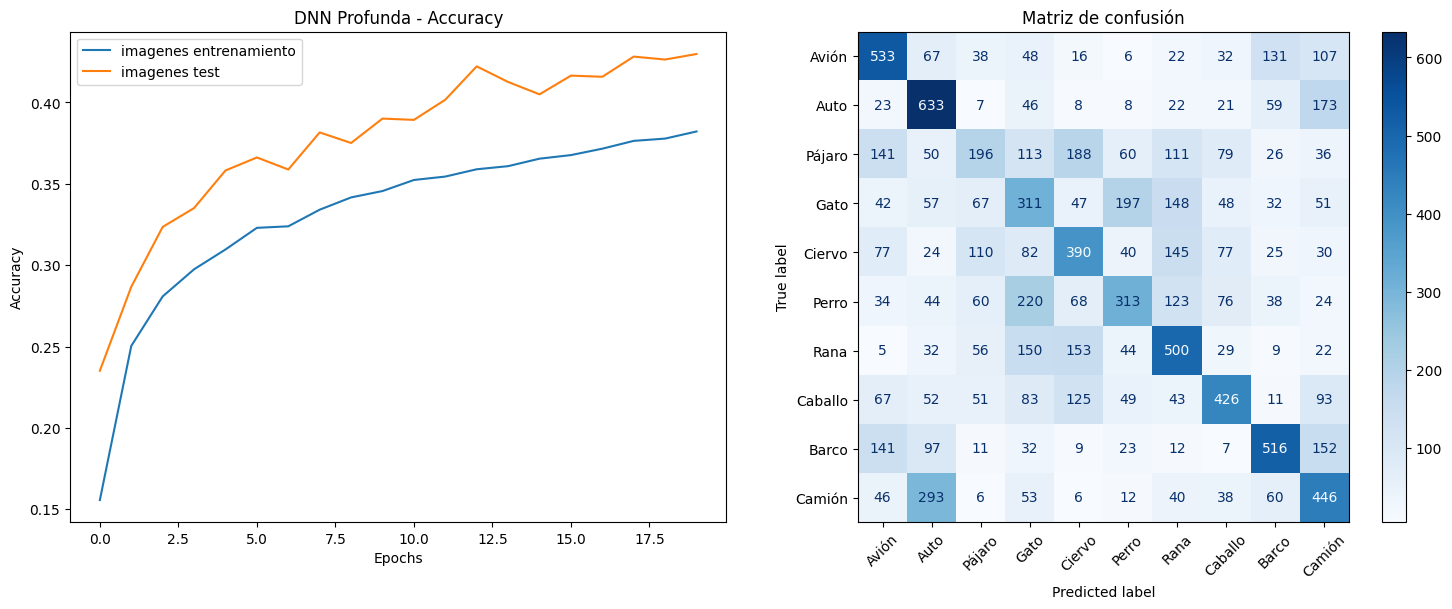

In [ ]:
# @title red profunda de 6 capas ocultas con regularización y droput
def crear_densa_profunda():
    model = Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Flatten(),
        layers.Dense(1024, activation='relu',kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(cant_clases, activation='softmax')
    ])
    return model

model_densa2 = crear_densa_profunda()
entrenar_y_evaluar(model_densa2, "DNN Profunda", 20, data_aug = True)

# 2. CNN basada en AlexNet


--- Entrenando: AlexNet por 25 epochs, rate: 0 (0 = default), loss: categorical_crossentropy ---


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 2048)           │     8,390,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,514,186 (108.77 MB)

 Trainable params: 28,514,186 (108.77 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 80ms/step - accuracy: 0.2359 - loss: 2.7160 - val_accuracy: 0.4667 - val_loss: 1.5245
Epoch 2/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.4576 - loss: 1.5418 - val_accuracy: 0.5239 - val_loss: 1.3700
Epoch 3/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 55ms/step - accuracy: 0.5275 - loss: 1.3642 - val_accuracy: 0.5825 - val_loss: 1.2588
Epoch 4/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.5605 - loss: 1.2858 - val_accuracy: 0.5863 - val_loss: 1.2340
Epoch 5/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.5979 - loss: 1.1894 - val_accuracy: 0.6372 - val_loss: 1.1176
Epoch 6/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.6227 - loss: 1.1331 - val_accuracy: 0.6808 - val_loss: 0.9834
Epoch 7/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.6407 - loss: 1.0859 - val_accuracy: 0.6865 - val_loss: 0.9835
Epoch 8/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.6546 - loss: 1.0447 - 

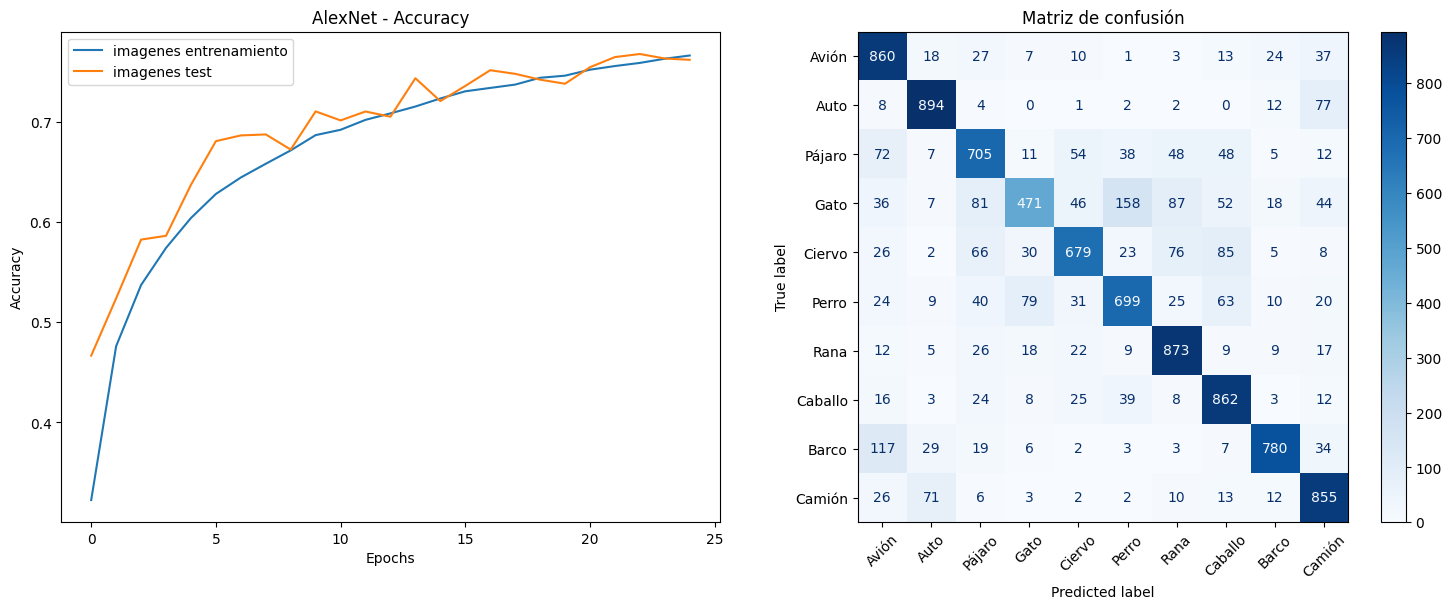

<Sequential name=sequential_10, built=True>

In [ ]:
# @title cnn basada en alexnet con regularización y dropout en el clasificador
# AlexNet original usa filtros de 11x11, lo cual es demasiado grande para una imagen de 32x32,
# se reduce el tamaño del kernel a 3x3 y se ajustan los filtros para mantener la estructura lógica pero a escala.
def crear_alexnet():
    model = Sequential([
        layers.Input(shape=(32, 32, 3)),

        # Capa 1
        layers.Conv2D(filters=96, kernel_size=3, padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)), # Salida: 16x16

        # Capa 2
        layers.Conv2D(filters=256, kernel_size=3, padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)), # Salida: 8x8

        # Capas 3, 4, 5
        layers.Conv2D(filters=384, kernel_size=3, padding='same', activation='relu'),
        layers.Conv2D(filters=384, kernel_size=3, padding='same', activation='relu'),
        layers.Conv2D(filters=256, kernel_size=3, padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)), # Salida: 4x4

        # Clasificador
        layers.Flatten(), # podría ser un pooling más? pero quedaría solo de 256, es muy chico creo, con esto funciona
        layers.Dense(4096, activation='relu',kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)),
        layers.Dropout(0.3),
        layers.Dense(2048, activation='relu'), # achicamos de 4096 para no tener tanto overfitting
        layers.Dropout(0.4),
        layers.Dense(cant_clases, activation='softmax')
    ])
    return model

alexnet = crear_alexnet()
entrenar_y_evaluar(alexnet, "AlexNet", 25, data_aug=True)


--- Entrenando: AlexNet plus por 25 epochs, rate: 0 (0 = default), loss: categorical_crossentropy ---


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 2048)           │     8,390,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,542,560 (326.32 MB)

 Trainable params: 28,514,186 (108.77 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 57,028,374 (217.55 MB)

Epoch 1/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 70ms/step - accuracy: 0.7566 - loss: 0.7849 - val_accuracy: 0.7622 - val_loss: 0.7976
Epoch 2/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.7631 - loss: 0.7672 - val_accuracy: 0.7682 - val_loss: 0.7786
Epoch 3/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.7668 - loss: 0.7490 - val_accuracy: 0.7545 - val_loss: 0.8119
Epoch 4/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.7710 - loss: 0.7513 - val_accuracy: 0.7636 - val_loss: 0.7982
Epoch 5/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.7717 - loss: 0.7505 - val_accuracy: 0.7688 - val_loss: 0.7856
Epoch 6/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.7749 - loss: 0.7380 - val_accuracy: 0.7643 - val_loss: 0.8020
Epoch 7/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.7730 - loss: 0.7402 - val_accuracy: 0.7734 - val_loss: 0.7539
Epoch 8/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.7827 - loss: 0.7116 - 

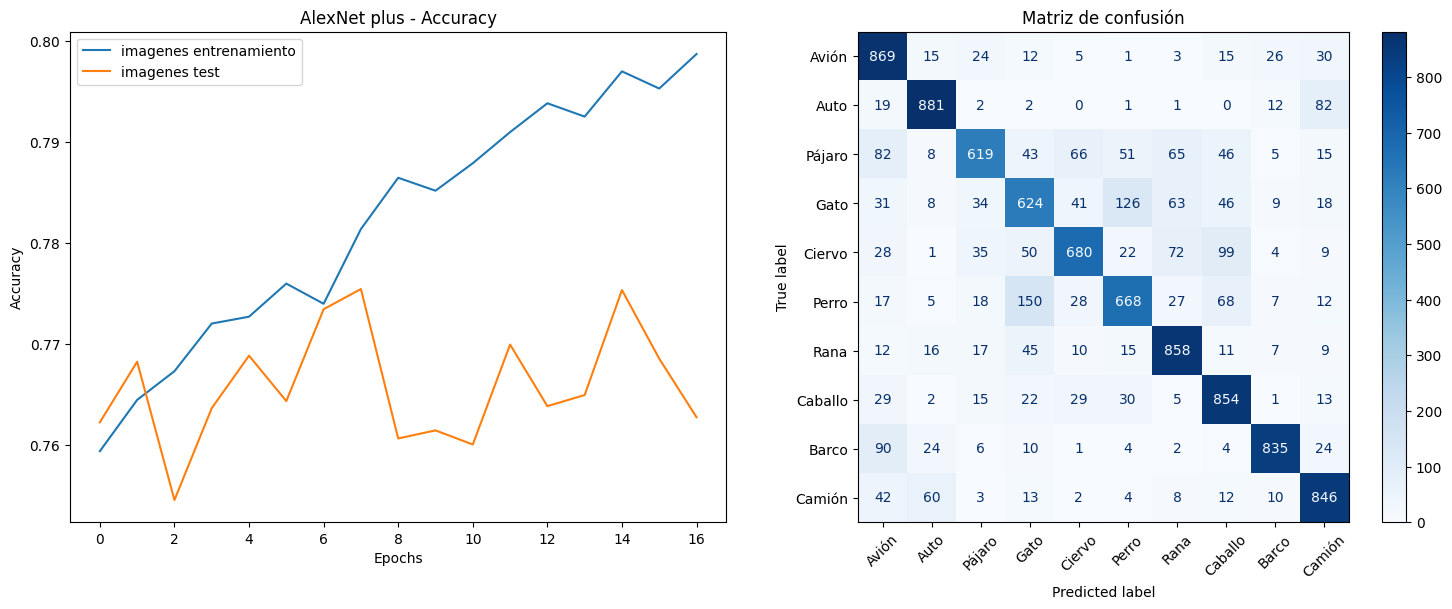

<Sequential name=sequential_10, built=True>

In [ ]:
# @title probamos de seguir entrenando ya que venía avanzando bastante
entrenar_y_evaluar(alexnet, "AlexNet plus", 25, data_aug=True)

# 3. Transfer learning



--- Entrenando: efficient net v2 b0 clasificador por 10 epochs, rate: 0 (0 = default), loss: categorical_crossentropy ---


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_5          │ (None, 128, 128,  │          0 │ input_layer_9[0]… │
│ (Resizing)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 128, 128,  │          0 │ resizing_5[0][0]  │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_5     │ (None, 128, 128,  │          0 │ rescaling_5[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        864 │ normalization_5[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 64, 64,    │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 64, 64,    │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 64, 64,    │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 32, 32,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 32, 32,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 32, 32,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 32, 32,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 32, 32,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 32, 32,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 32, 32,    │        512 │ block2b_expand_c

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 72s 111ms/step - accuracy: 0.5456 - loss: 1.3374 - val_accuracy: 0.8716 - val_loss: 0.4335
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.7158 - loss: 0.8278 - val_accuracy: 0.8789 - val_loss: 0.3904
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.7282 - loss: 0.7876 - val_accuracy: 0.8805 - val_loss: 0.3794
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.7314 - loss: 0.7846 - val_accuracy: 0.8820 - val_loss: 0.3732
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.7336 - loss: 0.7816 - val_accuracy: 0.8825 - val_loss: 0.3680
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.7359 - loss: 0.7666 - val_accuracy: 0.8839 - val_loss: 0.3664
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.7335 - loss: 0.7682 - val_accuracy: 0.8815 - val_loss: 0.3658
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.7374 - loss: 0.7642 -

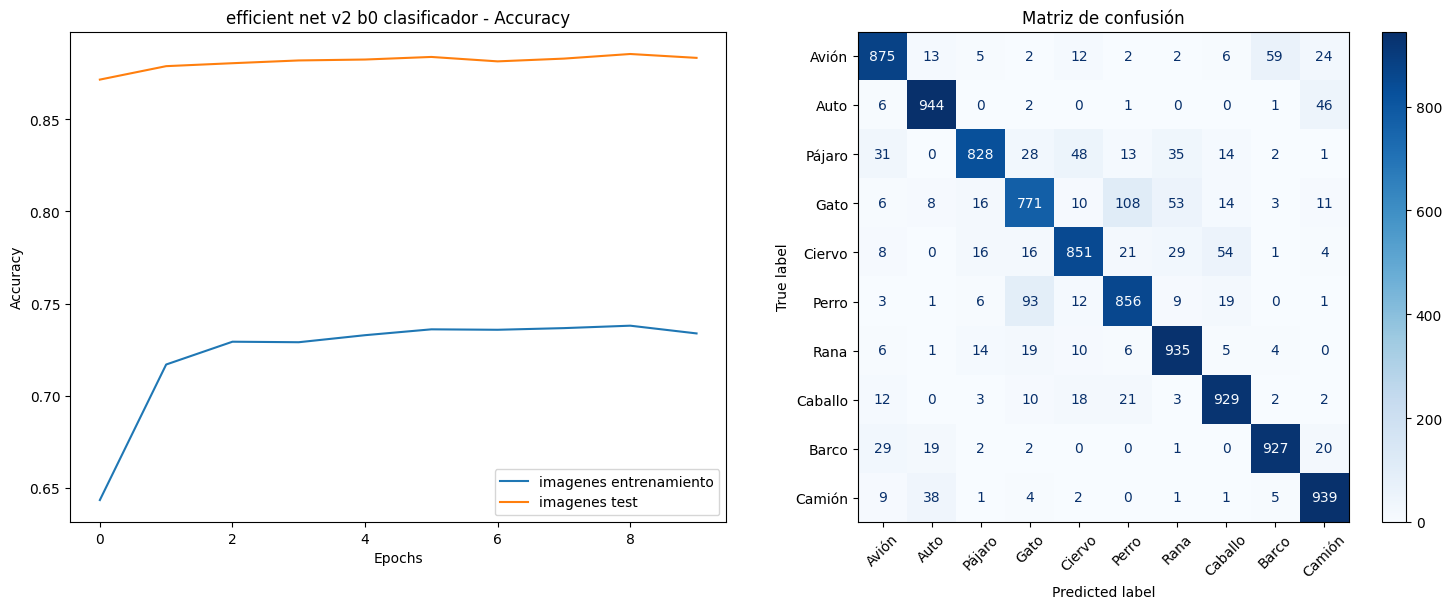

In [ ]:

# @title función para configurar red para transfer learning
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras import layers, models, optimizers
def crear_efficientnet_v2():
    inputs = layers.Input(shape=(32, 32, 3))
    x = layers.Resizing(128, 128)(inputs) # resize, razon explicada después en las conclusiones/informe
    base_model = EfficientNetV2B0(include_top=False, weights='imagenet', input_tensor=x) # cargar sin el clasificador

    base_model.trainable = False # congelar la red prerexistente
    x = base_model.output

    # clasificador para cifar 10
    x = layers.GlobalAveragePooling2D()(x) # acá un flatten no estaría tan mal, solo serían 4096, de todas formas con el avg pooling funciona más que bien
                                            # decidimos usar pooling cuando estabamos trabajando con resnet que un flatten sería de 200mil, pero se adaptó bien a efficient net
    x = layers.Dropout(0.5)(x) # con este dropout no presentó overfitting, no vimos necesario agregar una capa densa con regularización como en los incisos anteriores
    outputs = layers.Dense(cant_clases, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model, base_model

efnet_v2_entrenar, efnet_v2_base = crear_efficientnet_v2()

entrenar_y_evaluar(efnet_v2_entrenar,"efficient net v2 b0 clasificador",10, data_aug=True)

efnet_v2_entrenar.save('efnetv2b0-cifar10_clasificador_10epochs.keras')


--- Entrenando: efnetv2b0 finetune por 25 epochs, rate: 1e-05 (0 = default), loss: categorical_crossentropy ---


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_5          │ (None, 128, 128,  │          0 │ input_layer_9[0]… │
│ (Resizing)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 128, 128,  │          0 │ resizing_5[0][0]  │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_5     │ (None, 128, 128,  │          0 │ rescaling_5[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        864 │ normalization_5[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 64, 64,    │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 64, 64,    │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 64, 64,    │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 32, 32,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 32, 32,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 32, 32,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 32, 32,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 32, 32,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 32, 32,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 32, 32,    │        512 │ block2b_expand_c

 Total params: 5,957,744 (22.73 MB)

 Trainable params: 3,899,818 (14.88 MB)

 Non-trainable params: 2,032,304 (7.75 MB)

 Optimizer params: 25,622 (100.09 KB)

Epoch 1/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 110s 153ms/step - accuracy: 0.6264 - loss: 1.1076 - val_accuracy: 0.8490 - val_loss: 0.4876
Epoch 2/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.6875 - loss: 0.9187 - val_accuracy: 0.8685 - val_loss: 0.4137
Epoch 3/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.7204 - loss: 0.8246 - val_accuracy: 0.8798 - val_loss: 0.3768
Epoch 4/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.7388 - loss: 0.7723 - val_accuracy: 0.8866 - val_loss: 0.3523
Epoch 5/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.7548 - loss: 0.7213 - val_accuracy: 0.8922 - val_loss: 0.3291
Epoch 6/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.7682 - loss: 0.6772 - val_accuracy: 0.8984 - val_loss: 0.3134
Epoch 7/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.7729 - loss: 0.6629 - val_accuracy: 0.9021 - val_loss: 0.3025
Epoch 8/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.7830 - loss: 0.6346 

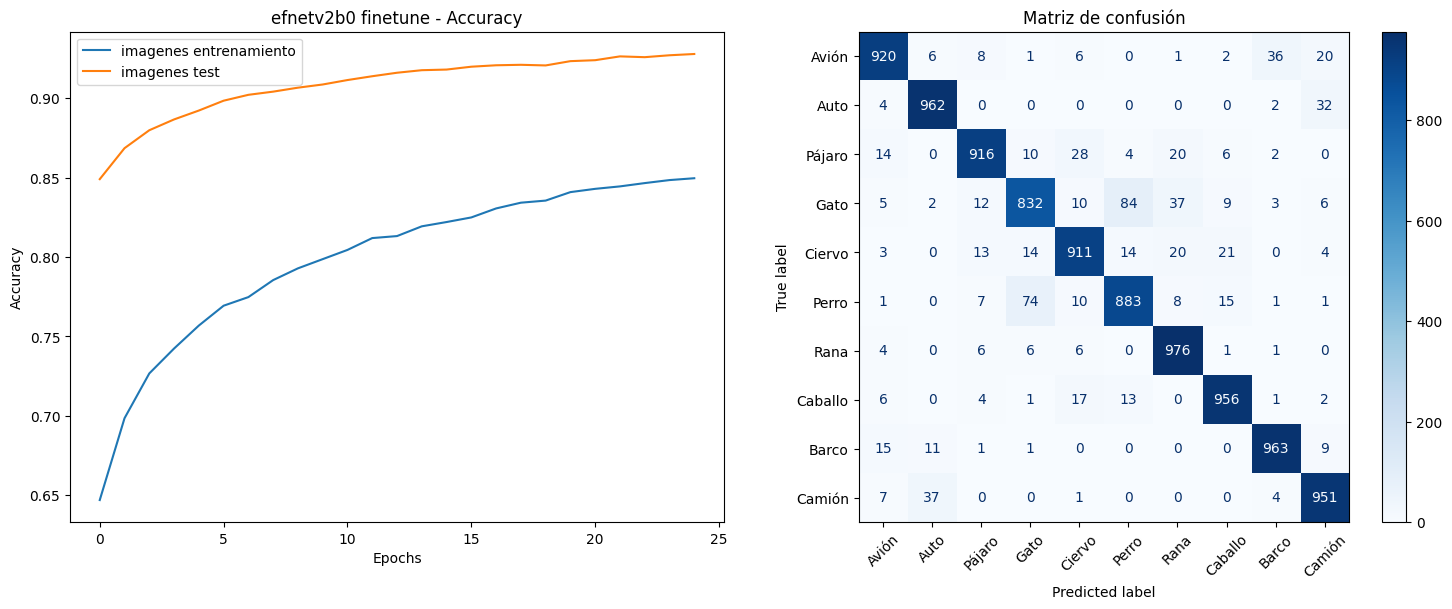

In [ ]:
efnet_v2_base.trainable = True

for layer in efnet_v2_base.layers[:174]:#el modelo tiene 274 capas, entrenamos las ultimas 100
    layer.trainable = False

# intentamos entrenar más pero crasheaba seguido el colab por quedarse sin memoria, esto es el maximo que conseguimos
# poder ejecutar de forma consistente
# no entendemos muy bien la razón del crasheo la verdad ya que el .summary() reporta que solo son unos cuantos MB de parametros, pero nos estaba pasando eso
# entendemos que el problema viene de que intenta cargar todo el dataset en memoria y luego sobreescalarlo, lo cual consume toda la memoria
# no profundizamos mucho más ya que igualmente los resultados de esta forma eran muy buenos y entendimos que entrenar toda la red era innecesario

entrenar_y_evaluar(efnet_v2_entrenar,"efnetv2b0 finetune",25, data_aug=True, rate= 1e-5) #para esto bajamos el learning rate asi no tiramos a cualquier lado los weigths del mod original
#para el clasificador estaba ok usar el rate default ya que estaba inicializado de forma random, pero aca se baja ya que queremos mantener en parte los pesos preexistentes

efnet_v2_entrenar.save('efnetv2b0_25epochs_100layers.keras')

# Dataset elegido:

Se eligió trabajar con CIFAR-10.

ImageNet fue descartado debido a su tamaño (~150GB de fotos) ya que no se cuenta con espacio suficiente en el entorno gratuito de Colab.

Oxford 102 también se descartó debido a que utiliza imágenes muy grandes y se observó en varios reportes que, al tener solo unas 10 imágenes por categoría, arrojaba resultados muy pobres sin utilizar transfer learning. El trabajo requiere mantener siempre el mismo dataset, incluso para los primeros incisos sin transfer learning.

Entre los datasets restantes, se decidió descartar MNIST dado que el objetivo (nuestro) era trabajar con imágenes a color. También se descartaron SVHN y Fashion-MNIST debido a que contienen categorías más restringidas (números y prendas respectivamente).

Por el contrario, los datasets CIFAR poseen categorías más generales. Esto fue una preferencia personal, si bien existen tantas o más diferencias entre tipos de pantalones o formas de hacer un '8' que las diferencias que puedan existir entre distintos autos, se prefirió trabajar con CIFAR.

Finalmente, se optó por CIFAR-10 sobre CIFAR-100 debido a que, si bien CIFAR-100 tiene más categorías, contiene la misma cantidad total de imágenes, por lo que los ejemplos de cada categoría son 10 veces menores.

# 1 Redes FC

En una primera instancia se trabajó con redes neuronales densas. Para estas se preveían resultados con baja precisión debido a que estos modelos no están pensados para trabajar con imágenes en 2D. Esto se debe a que para poder utilizarlos primero se debe aplanar la imagen en un vector, perdiéndose toda la información estructural y pasando a trabajar más con cada píxel por separado que con la imagen en sí.

Para ambos casos se utilizó data augmentation y regularización L1 y L2.

El resultado coincidió con lo esperado: un rendimiento estable a traves del entrenamiento con un accuracy bajo pero con una validación levemente superior. Esto se debe a la utilización de data augmentation, lo cual permite ir variando las imágenes con pequeñas modificaciones, y a su vez a la utilización de los regularizers que permiten reducir el overfitting.

Para la segunda red se pensaron dos posibles mejoras: aumentar la cantidad de capas disminuyendo su profundidad para generar una estructura decreciente, e implementar un drop-out para algunas capas variando entre 0.2 y 0.3, lo que descarta (apaga) aleatoriamente parte de las neuronas para reducir el overfitting. De todas formas, a pesar de estas supuestas mejoras, el modelo dió resultados casi iguales que la primera red.

Esto puede deberse a la pérdida de información por el drop-out en un modelo tan simple, y a que este tipo de redes no está pensado para el análisis de imágenes ya que se pierde la relación estructural de los píxeles. Por lo tanto, aumentar la cantidad de capas y/o neuronas no mejora la solución; es más información intermedia pero con un input igual de pobre.

De la matriz de confusión de estas redes neuronales se puede deducir que funcionan mejor en los objetos más discernibles como aviones, barcos y autos, donde quizás es más fácil encontrar patrones que identifiquen la imagen, como los patrones de cielo, nubes o agua de fondo, o un color característico como el de la rana. Sin embargo, en los animales que quizás son más similares entre sí y que normalmente no tienen patrones distinguidos en el escenario, la eficacia del modelo empeora, tal como sucede con los gatos y los perros.

En conclusión, aumentar considerablemente el tamaño de la red no mejora los resultados. El bottleneck en este caso es la arquitectura base de la red donde desde el momento cero se aplana la imagen a un vector, lo cual hace que la red detecte mayormente colores y no formas. En ambos casos se entrenó por 25 epochs y se observó cómo el accuracy ya estaba bastante estabilizado, por lo que se decidió no continuar entrenando.

# 2 Redes convolucionales

Se decidió partir de la base de la arquitectura de AlexNet, con la diferencia de que se eliminó el último bloque antes del clasificador para no reducir la imagen a 1x1 y tener el mismo problema anterior donde se perdía toda la información espacial durante el feature extraction. Por esta misma razón también se pasó de un kernel 11x11 a 3x3.

La arquitectura base de AlexNet se basa en ir reduciendo paulatinamente el tamaño de las capas para ir extrayendo features con cada bloque convolucional. Uno de sus puntos clave es el filtro 11x11, pero fue necesario reducirlo debido al dataset elegido. Incluso con esta modificación la estructura general de la red mostró ser muy eficaz.

Se implementó regularización L1 y L2 además de dropout en las capas densas del clasificador para evitar que la red quede sobreentrenada a las imágenes de entrenamiento.

Los resultados fueron considerablemente mejores que con las redes FC. Si bien se pasó de apenas 3 millones de parámetros a 28, el tiempo de entrenamiento siguió siendo viable (apenas unos cuantos minutos) y con las mismas 25 epochs ya se obtuvo un accuracy de 0.77 tanto en entrenamiento como en validación. Además, la curva de accuracy para las imágenes de validación resultó bastante suave, por lo que se puede decir que el modelo realmente generaliza a imágenes nuevas y no solo memoriza.

Como se observó que el accuracy seguía aumentando, se intentó entrenar por 25 epochs más, pero al tener activado el early stopping se frenó en el epoch 7. Después de la 25 las mejoras son marginales y principalmente en entrenamiento, no en validación, por lo que se considera que el punto correcto para entrenar esta arquitectura con el dataset CIFAR-10 está alrededor de las 25 epochs.

Quizá se podría continuar entrenando hasta un accuracy de 80-90% con regularización más agresiva o dropouts mayores, ya que el accuracy de entrenamiento sigue aumentando de forma bastante lineal mientras que el de validación se dispara y se vuelve errático.

# 3 Transfer learning

Para transfer learning se eligió usar de base EfficientNet V2 B0 entrenada con pesos de ImageNet (otro dataset general similar a CIFAR-10 pero de mucha mayor escala, para que la red ya estuviese expuesta desde el inicio a objetos como autos, aviones, barcos, gatos, etc.).

Primeramente se descargó el modelo ya entrenado pero sin el clasificador, ya que este está optimizado para las 1000 clases de ImageNet, por lo que serviría de poco y nada.

Es importante que en la primera capa se realice un sobreescalado de las imágenes; se encontró que de no hacerlo se reconocía todo como una sola clase ya que el modelo base espera una entrada de 240x240, por lo que todo parecía ser un punto o mancha en la pantalla.

Sobreescalar consume tiempo y memoria de video, por lo cual se decidió solo escalar a 128x128. Se entiende que un escalado bilineal no crea información nueva, pero igualmente adapta de cierta forma el dataset al modelo preentrenado para que las features que pueda encontrar sean más similares al tamaño original sin tener tanto coste computacional. Además, de no sobreescalar se seguiría teniendo el problema de colapsar todo antes del clasificador. Se reemplazó ese clasificador con un avg pooling del vec[1024] y una capa de 10 neuronas con activación softmax para representar las clases de interés.

Primero se entrenó solo el clasificador propio con un learning rate normal ya que está inicializado con pesos random. Esto dio un resultado sorprendentemente bueno, teniendo un accuracy de 0.88 en imágenes de validación. Es interesante ver cómo es mucho mejor en validación que con las mismas imágenes de entrenamiento gracias a la gran cantidad de imágenes con las que se entrenó el modelo base (todas las de ImageNet en 224x224).

Luego, se continuó entrenando sobre el clasificador ya sensibilizado, bajando el learning rate y trabajando sobre las últimas 100 capas. Esto logró sacarle un poco más de provecho a la red llegando a un accuracy de casi 0.93, número en el cual luego se quedó estancado.

Analizando la matriz de confusión se ve cómo las confusiones son 0 o casi 0 entre la mayoría de clases excepto en:

- predice gato y era perro: 74

- predice perro y era gato: 84

Una confusión que sinceramente sería aceptable hasta para un humano dada la bajísima resolución de CIFAR-10. Viendo algunas imágenes del dataset, el sujeto es simplemente un manchón en el centro de la imagen, especialmente para los colores más comunes de estos animales y cuando están sentados, lo cual hace más difícil aún diferenciarlos.

Luego, en menor escala, otra de las confusiones más comunes es mezclar avión, barco y pájaro, por lo que se entiende que el modelo está aprendiendo el patrón de un fondo azul, lo mismo con auto y camión donde se entiende que está aprendiendo a buscar las ruedas del vehículo y un camino de asfalto presente en la imagen.

Los resultados fueron más que satisfactorios, más aún considerando que solo se entrenaron ~4 millones de parámetros, lo mismo que con las redes densas de los primeros incisos las cuales no alcanzaban ni un 0.5.

# Conclusiones:

Transfer learning resultó ser el método más eficiente para un caso como este donde se tienen limitaciones de memoria y no se pueden cargar datasets masivos como ImageNet.

Permite tener un modelo que esté expuesto de entrada a miles de conceptos o clases y obtener resultados muy superiores a cualquier otro método en poquísimas epochs. No se considera que esto sea una ventaja inherente de una red como EfficientNet sino del dataset original con el que fue entrenada; esta es una de las mayores ventajas de transfer learning.

Mientras alguien haya entrenado alguna arquitectura de interés con un dataset que tenga cierto overlap con el que se va a usar, se puede adaptar simplemente con un clasificador pequeñísimo y obtener resultados muy buenos. Luego, con 25 a 30 minutos extra de fine tuning, se llega a resultados casi perfectos donde los errores son mínimos y entre clases muy similares, sobre todo considerando la resolución de las imágenes utilizadas.

En resumen, se concluye que la calidad y cantidad de datos que se usen es igual o más importante que la arquitectura de la red. Con buenos datos se obtendrán buenos resultados (asumiendo una red aceptable), mientras que incluso con una red buena se pueden tener pésimos resultados si los datos de entrenamiento son malos (o si se hacen malos en el camino, como sucede cuando se colapsa a 1 dimensión antes de clasificar), ya que por muy buena que sea la arquitectura de la red aprendiendo, no sirve de nada que aprenda cosas incorrectas.